In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
import pandas as pd
titanic_df = pd.read_csv("/content/drive/MyDrive/dsml12/titanic-data.csv")

In [115]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [116]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Inserting and Deleting Columns and Rows**

In [117]:
titanic_df.drop([0, 2, 5], axis=0, inplace=True)

In [118]:
last_name = [name.split(",")[0] for name in titanic_df['Name']]
titanic_df["last_name"] = last_name

In [119]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Palsson


In [120]:
# Age Category

bins = [0,12,18,35,60,100]

labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]

titanic_df["Age_Category"] = pd.cut(
    titanic_df["Age"],
    bins=bins,
    labels=labels
)

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,Age_Category
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Young Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Adult
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Palsson,Child
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Montvila,Young Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Young Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Young Adult


In [121]:
# for name in titanic_df['Name']:
#   print(name.split(",")[0])

In [122]:
# Adding the row


In [123]:
# # Insert into row

# titanic_df.loc[900, :] = [0,3,1,"Priyansh, Shah", "male", 22.0,1.0,0,"A5 324", 7.34, "C12","C"]

**HAndling NAN or Null Value**

In [124]:
titanic_df.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,Age_Category
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False,False,True
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [125]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,176
SibSp,0
Parch,0
Ticket,0
Fare,0


In [127]:
# Handling

# 1) Remove null values
# 2) Imputation (Replacing null value with some value)

In [128]:
# Remove null values

titanic_df_filter = titanic_df.dropna(subset="Embarked", axis=0, how="all", ignore_index=True)


In [129]:
titanic_df_filter.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,176
SibSp,0
Parch,0
Ticket,0
Fare,0


This determines when to remove a row.

how="any" → Remove the row if any checked value is NaN.

how="all" → Remove the row only if all checked values are NaN.

In [130]:
titanic_df_filter.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,Age_Category
0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Adult
1,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Young Adult
2,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Young Adult
3,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Adult
4,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Palsson,Child


In [131]:
titanic_df.Age.mean()

np.float64(29.71512640449438)

<Axes: ylabel='Frequency'>

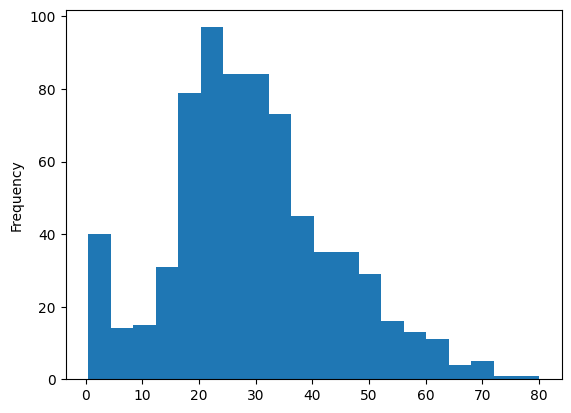

In [132]:
titanic_df.Age.plot.hist(bins = 20)

In [133]:
mean_age = titanic_df.Age.mean()

In [134]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,176
SibSp,0
Parch,0
Ticket,0
Fare,0


In [135]:
titanic_df["Age"].fillna(mean_age, axis=0, inplace=True)

In [136]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: ylabel='Frequency'>

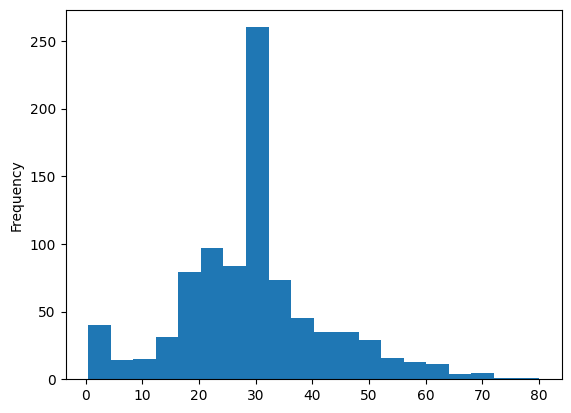

In [137]:
titanic_df.Age.plot.hist(bins=20)

In [138]:
# Research topic
# MICE Algorithm

In [139]:
# Imputation of Age column w.r.t gender provided

In [140]:
titanic_df_2 = pd.read_csv("/content/drive/MyDrive/dsml12/titanic-data.csv")

In [141]:
titanic_df_2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [142]:
mean_ages = titanic_df_2.groupby("Sex")["Age"].transform("mean")

In [143]:
mean_ages

,Age
0,30.726645
1,27.915709
2,27.915709
3,27.915709
4,30.726645
...,...
886,30.726645
887,27.915709
888,27.915709
889,30.726645


In [144]:
titanic_df_2["Age"].fillna(mean_ages, inplace=True)

/tmp/ipykernel_7135/3471555883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df_2["Age"].fillna(mean_ages, inplace=True)


In [145]:
titanic_df_2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,27.915709,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


<Axes: ylabel='Frequency'>

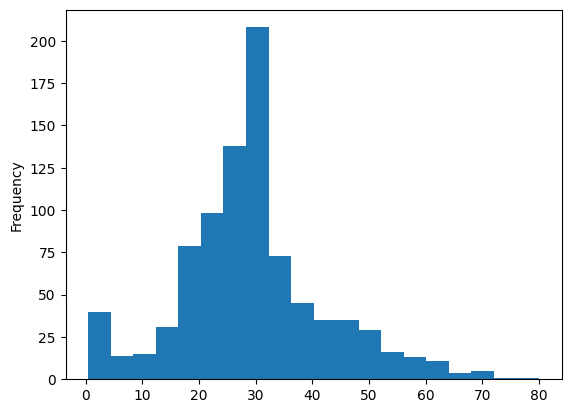

In [146]:
titanic_df_2.Age.plot.hist(bins=20)

In [147]:
titanic_df_2.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [148]:
import pandas as pd

# 1. Create a sample DataFrame
df = pd.DataFrame({
    'Store': ['A', 'A', 'B', 'B', 'B'],
    'Sales': [100, 200, 150, 250, 500]
})

# 2. Calculate the group mean and assign it to a new column
df['Store_Mean_Sales'] = df.groupby('Store')['Sales'].transform('mean')

print(df)

  Store  Sales  Store_Mean_Sales
0     A    100             150.0
1     A    200             150.0
2     B    150             300.0
3     B    250             300.0
4     B    500             300.0


In [149]:
# Feature from Null values

titanic_df.Cabin

,Cabin
1,C85
3,C123
4,NaN
6,E46
7,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


In [150]:
titanic_df.Cabin = titanic_df.Cabin.notna().astype(int)

In [151]:
titanic_df.Cabin

,Cabin
1,1
3,1
4,0
6,1
7,0
...,...
886,0
887,1
888,0
889,1


In [152]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

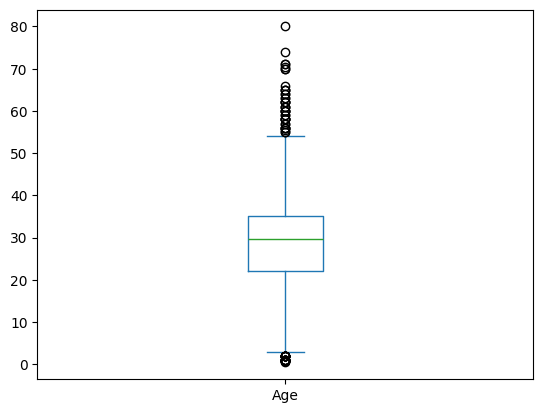

In [153]:
titanic_df.Age.plot.box()